# CNN, MNIST 예제

In [2]:
import os
import torch
from torch import nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

generator = torch.Generator().manual_seed(42)  # 독립적인 난수 시퀀스 생성
# 많은 pytorch 함수에 generator= 매개변수가 있다.  여기서 사용가능.


In [3]:
# GPU 사용 가능 여부를 확인하고, 가능하다면 GPU(cuda), 아니면 CPU 사용 할거다
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.11.0+cu128, Device: cuda


# Conv2d
- 2D 함성곱 층

**torch.nn.Conv2d**

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

```python
class torch.nn.Conv2d(
  in_channels,  # 입력 채널 (*필수)
  out_channels,  # 출력 채널 (필터의 개수) (*필수)
  kernel_size,  # 필터에 사용할 커널의 크기 (*필수)
  stride=1,      # 스트라이드, 필터 이동 크기
  padding=0,    # 패딩의 크기
  dilation=1,
  groups=1,
  bias=True,
  padding_mode='zeros',
  device=None,
  dtype=None)
```




## in_channels=, out_channels=, kernel_size=

In [4]:
nn.Conv2d(in_channels=1, out_channels=10, kernel_size=(3, 3))

Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))

## Max pooling

**torch.nn.MaxPool2d**

https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html


```python
class torch.nn.MaxPool2d(
  kernel_size, # pool size
  stride=None,
  padding=0,
  dilation=1,
  return_indices=False,
  ceil_mode=False)

```
- strides 값이 None 으로 주어지면 kernel_size 와 동일한 크기로 stride 한다

In [5]:
nn.MaxPool2d(kernel_size=2)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

# 데이터 셋 준비

In [6]:
train_dataset = datasets.MNIST(
    root='MNIST_data/',
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

test_dataset = datasets.MNIST(
    root='MNIST_data/',
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.15MB/s]


In [7]:
classes = train_dataset.classes
classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 학습/검증 데이터셋 분리: random_split()

In [8]:
# 데이터셋 분할
# 학습 데이터셋을 85% 학습용, 15% 검증용으로 분할.
# 검증(validation)은 모델의 일반화 성능을 평가하는 데 사용.


train_dataset_size = int(len(train_dataset) * 0.85)
validation_dataset_size = int(len(train_dataset) * 0.15)

train_dataset, validation_dataset = random_split(train_dataset,
 [train_dataset_size, validation_dataset_size], generator=generator)

print(train_dataset_size, validation_dataset_size, len(test_dataset))

51000 9000 10000


## DataLoader

In [9]:
# DataLoader: 데이터셋을 batch 단위로 나누어 학습에 공급.
# batch_size= → 한 번의 학습 step에 batch_size개 이미지 사용.
# shuffle=True → 매 epoch마다 데이터 순서를 섞어서 모델이 순서에 의존하지 않도록 함.
# generator=   random seed

BATCH_SIZE = 64   # 미니배치 학습 단위. 이번에는 batch 크기를 좀더 크게 잡음

In [10]:
train_dataset_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
validation_dataset_loader = DataLoader(dataset=validation_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
test_dataset_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

# 모델 정의 & 생성

In [11]:
class MyCNNModel(nn.Module):

  def __init__(self):
    """모델에 사용할 레이어들"""

    super().__init__()

    # 입력: 1채널(흑백) 28×28 이미지.
    # conv1: (1→32채널, 3×3 커널), 출력 28×28.
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

    # conv2: (32→64채널, 3×3 커널), 출력 14×14.
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

    # pooling: 크기 절반 (ex: 28 -> 14)
    self.pooling = nn.MaxPool2d(kernel_size=2, stride=2)


    # fully connected
    self.fc1 = nn.Linear(in_features=7 * 7 * 64, out_features=256)

    # 최종출력 10 클래스
    self.fc2 = nn.Linear(in_features=256, out_features=10)

    # Dropout
    self.dropout25 = nn.Dropout(p=0.25)
    self.dropout50 = nn.Dropout(p=0.5)

  def forward(self, data):
    """입력 data 로부터 모델 출력까지의 순방향 정의"""

    # [Feature extration]
    data = self.conv1(data)
    data = torch.relu(data)
    data = self.pooling(data)
    data = self.dropout25(data)

    data = self.conv2(data)
    data = torch.relu(data)
    data = self.pooling(data)
    data = self.dropout25(data)

    # [Classification]

    data = data.view(-1, 7 * 7 * 64)

    data = self.fc1(data)
    data = torch.relu(data)
    data = self.dropout50(data)

    logits = self.fc2(data)

    return logits   # softmax 적용전 상태로 모델 출력.



In [12]:
# DEVICE (GPU 혹은 CPU) 로 모델 이동
model = MyCNNModel().to(DEVICE)

# 모델 파라미터 확인

In [13]:
for name, child in model.named_children():
  print('🔶', name)
  # print(child)
  total = 0
  for param_name, param in child.named_parameters():
    print('  🟡', f"{param_name:9s}", ":", f"{param.numel()}개", "←", param.data.shape)
    total += param.numel()

  total and print('  [total params]:', f"{total:,}개") # parameter 있는 레이어만 출력
  print()


🔶 conv1
  🟡 weight    : 288개 ← torch.Size([32, 1, 3, 3])
  🟡 bias      : 32개 ← torch.Size([32])
  [total params]: 320개

🔶 conv2
  🟡 weight    : 18432개 ← torch.Size([64, 32, 3, 3])
  🟡 bias      : 64개 ← torch.Size([64])
  [total params]: 18,496개

🔶 pooling

🔶 fc1
  🟡 weight    : 802816개 ← torch.Size([256, 3136])
  🟡 bias      : 256개 ← torch.Size([256])
  [total params]: 803,072개

🔶 fc2
  🟡 weight    : 2560개 ← torch.Size([10, 256])
  🟡 bias      : 10개 ← torch.Size([10])
  [total params]: 2,570개

🔶 dropout25

🔶 dropout50



# 손실함수 & optimizer

In [14]:
# 손실 함수: CrossEntropyLoss
#     softmax + negative log likelihood 결합.  <- softmax 함수가 포함되어 있다
#     다중 분류 문제에서 자주 사용.

loss_function = nn.CrossEntropyLoss()

# Adam optimizer, 학습률 0.001
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

# train, eval, test 함수 정의

In [15]:
def model_train(dataloader, model, loss_function, optimizer):

  model.train()   # 학습모드 (Dropout 활성화)

  train_loss_sum = train_correct = train_total = 0

  total_train_batch = len(dataloader)  # 배치의 개수

  # 각 배치 순환
  for images, labels in dataloader:

    x_train = images.to(DEVICE)  # 모델과 동일 DEVICE 로 이동
    y_train = labels.to(DEVICE)

    outputs = model(x_train)  # 입력 -> 모델의 forward 호출
    # outputs 의 형태는 (batch, 10)
    loss = loss_function(outputs, y_train)  # 손실(loss) 계산.

    optimizer.zero_grad()  # 기울기 초기화
    loss.backward()  # 역전파,  기울기 계산
    optimizer.step()   # 최적화로 가중치 업데이트!

    train_loss_sum += loss.item()  # 매 batch 마다의 loss 값 누적 합산

    train_total += y_train.size(0) # 데이터개수도 누적

    # torch.argmax(outputs, dim=1)  예측값. 차원1의 최댓값 인덱스 -> 결과 (batch,)  정수인덱스 (0~9)
    # torch.argmax(outputs, dim=1) == y_train  정답비교결과 True, False 로 이루어진 1차원
    # (torch.argmax(outputs, dim=1) == y_train).sum().item()  맞춘개수 True 의 개수
    train_correct += (torch.argmax(outputs, dim=1) == y_train).sum().item()

  # 평균 loss, accuracy 계산
  train_avg_loss = train_loss_sum / total_train_batch
  train_avg_accuracy = 100 * train_correct / train_total

  return train_avg_loss, train_avg_accuracy


In [16]:
def model_evaluate(dataloader, model, loss_function, optimizer):

  model.eval()   # 평가모드 (Dropout 비활성화)

  with torch.no_grad():  # 기울기(gradient) 계산 비활성화

    val_loss_sum = val_correct = val_total = 0

    total_val_batch = len(dataloader)  # 배치의 개수

    # 각 배치 순환
    for images, labels in dataloader:

      x_val = images.to(DEVICE)  # 모델과 동일 DEVICE 로 이동
      y_val = labels.to(DEVICE)

      outputs = model(x_val)  # 입력 -> 모델의 forward 호출
      loss = loss_function(outputs, y_val)  # 손실(loss) 계산.

      val_loss_sum += loss.item()  # 매 batch 마다의 loss 값 누적 합산

      val_total += y_val.size(0) # 데이터개수도 누적
      val_correct += (torch.argmax(outputs, dim=1) == y_val).sum().item()

    # 평균 loss, accuracy 계산
    val_avg_loss = val_loss_sum / total_val_batch
    val_avg_accuracy = 100 * val_correct / val_total

  return val_avg_loss, val_avg_accuracy


In [17]:
# 검증 함수와 비슷하지만, 최종 성능(accuracy, loss)만 출력.
def model_test(dataloader, model):

    model.eval()

    with torch.no_grad():

        test_loss_sum = test_correct = test_total = 0

        total_test_batch = len(dataloader)

        for images, labels in dataloader:

            x_test = images.to(DEVICE)
            y_test = labels.to(DEVICE)

            outputs = model(x_test)
            loss = loss_function(outputs, y_test)

            test_loss_sum += loss.item()

            test_total += y_test.size(0)
            test_correct += ((torch.argmax(outputs, 1)==y_test)).sum().item()

        test_avg_loss = test_loss_sum / total_test_batch
        test_avg_accuracy = 100*test_correct / test_total

        print('accuracy:', test_avg_accuracy)
        print('loss:', test_avg_loss)

# 학습 함수 정의

In [18]:
def train(model, epochs,
          train_dataset_loader, validation_dataset_loader,
          loss_function, optimizer):

  # epoch 마다의 loss & accuracy 값 기록
  train_loss_list = []
  train_accuracy_list = []

  val_loss_list = []
  val_accuracy_list = []

  start_time = datetime.now()

  for epoch in range(epochs):

    # ============== model train ==================
    train_avg_loss, train_avg_accuracy = model_train(train_dataset_loader, model, loss_function, optimizer)
    train_loss_list.append(train_avg_loss)
    train_accuracy_list.append(train_avg_accuracy)


    # ============== model evaluation ==================
    val_avg_loss, val_avg_accuracy = model_evaluate(validation_dataset_loader, model, loss_function, optimizer)
    val_loss_list.append(val_avg_loss)
    val_accuracy_list.append(val_avg_accuracy)


    print('epochs:', '%02d' % (epoch + 1),
      'train loss =', '{:.4f}'.format(train_avg_loss), 'train acc =', '{:.4f}'.format(train_avg_accuracy),
      'val loss =', '{:.4f}'.format(val_avg_loss), 'val acc =', '{:.4f}'.format(val_avg_accuracy))


  end_time = datetime.now()

  print('elapsed time => ', end_time-start_time)

  return train_loss_list,train_accuracy_list, val_loss_list, val_accuracy_list



# 훈련

In [19]:
# 20 epoch 동안 학습 진행.
# 각 epoch마다 학습/검증 손실 및 정확도 출력.
# 결과는 리스트에 저장 → 이후 시각화 가능.

train_loss_list, train_accuracy_list, val_loss_list, val_accuracy_list =\
  train(model, 20,
        train_dataset_loader, validation_dataset_loader,
        loss_function, optimizer);

epochs: 01 train loss = 0.3025 train acc = 90.4314 val loss = 0.0708 val acc = 97.8333
epochs: 02 train loss = 0.1024 train acc = 96.9176 val loss = 0.0572 val acc = 98.3889
epochs: 03 train loss = 0.0807 train acc = 97.4824 val loss = 0.0418 val acc = 98.8333
epochs: 04 train loss = 0.0627 train acc = 98.0843 val loss = 0.0425 val acc = 98.7222
epochs: 05 train loss = 0.0581 train acc = 98.2373 val loss = 0.0392 val acc = 98.8667
epochs: 06 train loss = 0.0513 train acc = 98.4490 val loss = 0.0351 val acc = 98.9667
epochs: 07 train loss = 0.0458 train acc = 98.5745 val loss = 0.0408 val acc = 98.8889
epochs: 08 train loss = 0.0426 train acc = 98.6490 val loss = 0.0320 val acc = 99.1000
epochs: 09 train loss = 0.0372 train acc = 98.8451 val loss = 0.0302 val acc = 99.1222
epochs: 10 train loss = 0.0354 train acc = 98.8863 val loss = 0.0303 val acc = 99.1889
epochs: 11 train loss = 0.0324 train acc = 98.9529 val loss = 0.0311 val acc = 99.1556
epochs: 12 train loss = 0.0307 train acc = 

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
base_path = r'/content/drive/MyDrive/KDT-2604/dataset'

In [22]:
# 저장하기
save_path = os.path.join(base_path, 'out', 'CNN_MNIST.pth')
torch.save(model.state_dict(), save_path)

In [23]:
# 불러오기
model = MyCNNModel().to(DEVICE)
model.load_state_dict(torch.load(save_path))

<All keys matched successfully>

# 성능 테스트

In [24]:
model_test(test_dataset_loader, model)

accuracy: 99.29
loss: 0.0235780904528438


# Loss Curve
손실곡선

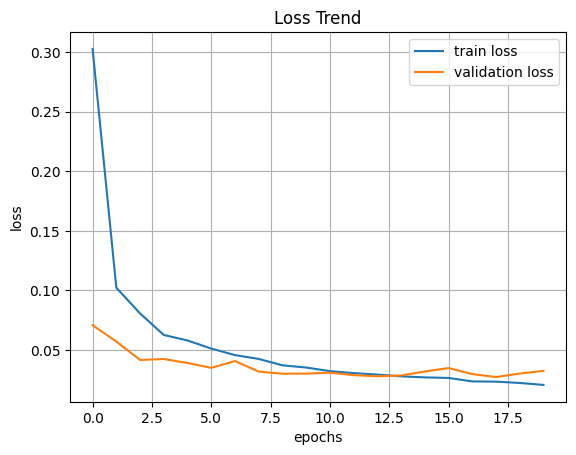

In [25]:
plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()

plt.plot(train_loss_list, label='train loss')
plt.plot(val_loss_list, label='validation loss')

plt.legend()

plt.show()

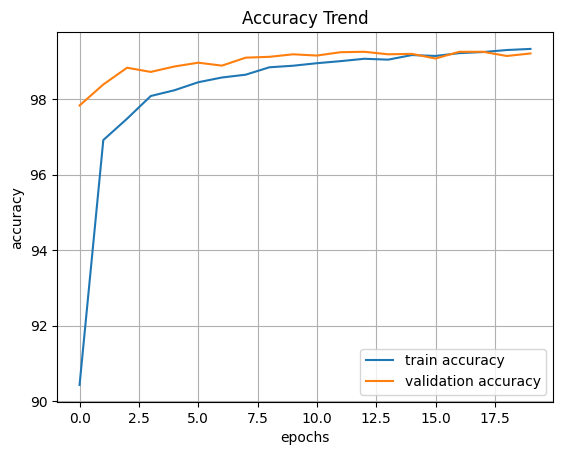

In [27]:
plt.title('Accuracy Trend')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()

plt.plot(train_accuracy_list, label='train accuracy')
plt.plot(val_accuracy_list, label='validation accuracy')

plt.legend()

plt.show()

# 예측, 실제 데이터 적용해보기

- 학습한 크기과는 다른 크기, 다른 색상채널(RGB), 다른 파일 포맷의 이미지 입력을 실제로 모델에 적용할시 예측값을 출력해봅니다

- 이를 함수로 만들어 동작시켜 봅니다. ( **predict()** )

- 테스트해볼 이미지를 4종류 이상 준비하여 실행한 결과를 출력해보세요 (예측값 + 시각화)


- **HINT**
    - 이미지의 사이즈 변환
    - 이미지 흑백 채널로 변환
    - 이미지 반전
    - 이미지 scaling
    - 이미지 차원변환 -> 모델에 입력하는 형태로
   
    - 위 이미지 조작을 손쉽게 다루기 위해 **pillow** 모듈 추천.
    - 필요시 설치하고 진행


In [28]:
from PIL import Image
import PIL.ImageOps as ops

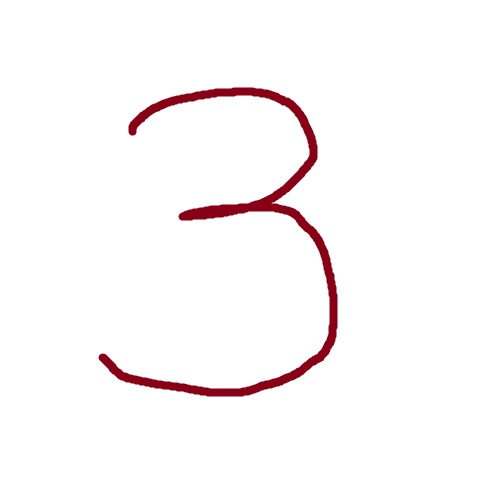

In [29]:
img = Image.open(os.path.join(base_path, 'MNIST', 'img_3.jpg'))
img

In [30]:
img.size

(500, 500)

In [31]:
len(img.getdata())  # 500 x 500

250000

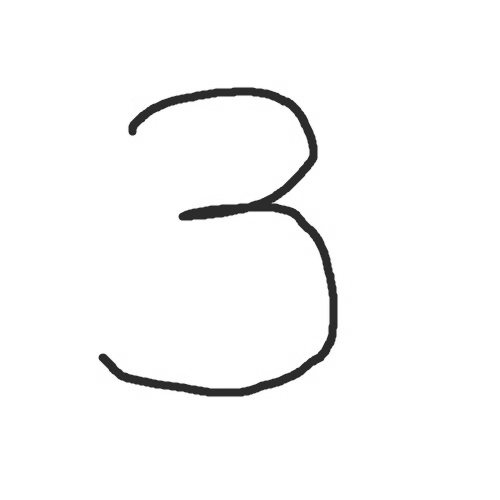

In [32]:
mono8img = img.convert('L')
mono8img

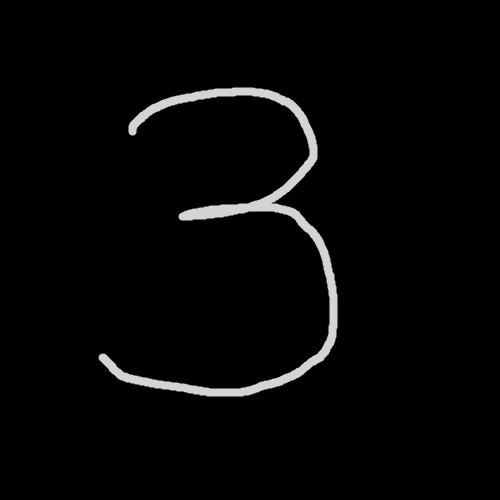

In [35]:
invImg = ops.invert(mono8img)
invImg

In [36]:
# 전처리

transform = transforms.Compose([
    transforms.Resize((28, 28)),   # resize
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,)),
])

In [37]:
transformed_img = transform(invImg)
transformed_img.shape

torch.Size([1, 28, 28])

In [38]:
# 배치 차원 추가
img_tensor = transformed_img.unsqueeze(0)
img_tensor.shape

torch.Size([1, 1, 28, 28])

In [39]:
# 모델과 동일한 device 에 이동
img_tensor = img_tensor.to(DEVICE)

In [40]:
# 예측
with torch.no_grad():
  logits = model(img_tensor)
  probs = torch.softmax(logits, dim=1)
  predicted_class = torch.argmax(probs, dim=1).item()


print(f"예측된 숫자: {predicted_class} - {classes[predicted_class]}")

예측된 숫자: 3 - 3 - three


In [41]:
# 함수로 만들기
from PIL import Image
import PIL.ImageOps as ops


def predict(file_path):
    img = Image.open(file_path)
    mono8img = img.convert('L')
    invImg = ops.invert(mono8img)

    transform = transforms.Compose([
        transforms.Resize((28, 28)),  # resize
        transforms.ToTensor(),  # 스케일링, 차원변환
    ])

    transformed_img = transform(invImg)
    img_tensor = transformed_img.unsqueeze(0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)  # 모델도,
    img_tensor = img_tensor.to(device)  # 입력 텐서도.

    # 예측 수행
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()

    print(f"예측된 숫자: {predicted_class} - {classes[predicted_class]}")

In [43]:
from glob import glob

file_paths = glob(os.path.join(base_path, 'MNIST', 'img*.*'))

예측된 숫자: 7 - 7 - seven


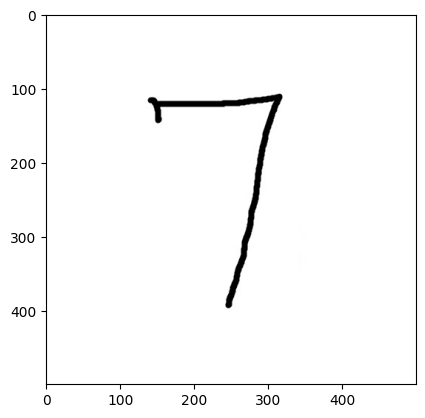

예측된 숫자: 5 - 5 - five


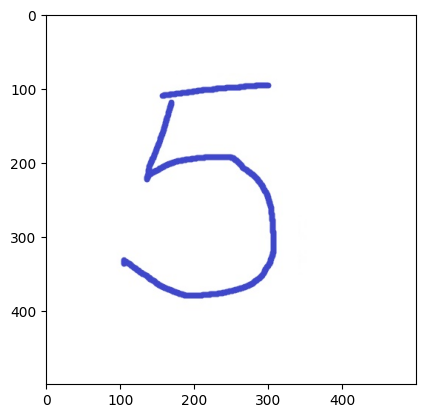

예측된 숫자: 3 - 3 - three


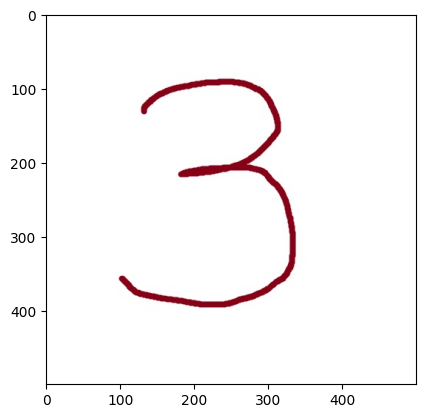

In [44]:
for file_path in file_paths:
  predict(file_path)
  plt.imshow(Image.open(file_path))
  plt.show()

# PyTorch가 더 어려운데 왜 PyTorch 많이 쓸까?

In [45]:
# Keras 는 편하지만,  '정해진틀' 을 벗어나기 어렵다.
#     Keras 는 정적그래프 : define and run

# Python 은 '자유롭다' : 복잡한 기능 동작 구현 가능.
#     동적으로 그래프 구성 가능

# 연구 / 커뮤니티 분야에선 사실상 표준
# 새로운 논문 / 기법들이 PyTorch로 먼저 나오는 추세


# Tensorflow / Keras가 우세한 영역 -> 엣지 디바이스 배포
#                                 엣지 디바이스? -> 데이터가 발생하는 현장 가까이에서 데이터를 직접 처리하는 기기(모바일 등)